In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

In [47]:
dataset = pd.read_csv('C:\\Users\\tript\\Desktop\\kiddny_Disease_model\\kidney_disease_dataset.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [49]:
data = pd.read_csv("C:\\Users\\tript\\Desktop\\kiddny_Disease_model\\kidney_disease_dataset.csv")
data.head(3)


,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease


In [9]:
data.isnull().sum()

Age of the patient                             0
Blood pressure (mm/Hg)                         0
Specific gravity of urine                      0
Albumin in urine                               0
Sugar in urine                                 0
Red blood cells in urine                       0
Pus cells in urine                             0
Pus cell clumps in urine                       0
Bacteria in urine                              0
Random blood glucose level (mg/dl)             0
Blood urea (mg/dl)                             0
Serum creatinine (mg/dl)                       0
Sodium level (mEq/L)                           0
Potassium level (mEq/L)                        0
Hemoglobin level (gms)                         0
Packed cell volume (%)                         0
White blood cell count (cells/cumm)            0
Red blood cell count (millions/cumm)           0
Hypertension (yes/no)                          0
Diabetes mellitus (yes/no)                     0
Coronary artery dise

In [11]:
data.shape

(20538, 43)

In [13]:
data.dtypes

Age of the patient                               int64
Blood pressure (mm/Hg)                           int64
Specific gravity of urine                      float64
Albumin in urine                                 int64
Sugar in urine                                   int64
Red blood cells in urine                        object
Pus cells in urine                              object
Pus cell clumps in urine                        object
Bacteria in urine                               object
Random blood glucose level (mg/dl)               int64
Blood urea (mg/dl)                             float64
Serum creatinine (mg/dl)                       float64
Sodium level (mEq/L)                           float64
Potassium level (mEq/L)                        float64
Hemoglobin level (gms)                         float64
Packed cell volume (%)                           int64
White blood cell count (cells/cumm)              int64
Red blood cell count (millions/cumm)           float64
Hypertensi

In [15]:
print(data.columns)

Index(['Age of the patient', 'Blood pressure (mm/Hg)',
       'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine',
       'Red blood cells in urine', 'Pus cells in urine',
       'Pus cell clumps in urine', 'Bacteria in urine',
       'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)',
       'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)',
       'Potassium level (mEq/L)', 'Hemoglobin level (gms)',
       'Packed cell volume (%)', 'White blood cell count (cells/cumm)',
       'Red blood cell count (millions/cumm)', 'Hypertension (yes/no)',
       'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)',
       'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)',
       'Estimated Glomerular Filtration Rate (eGFR)',
       'Urine protein-to-creatinine ratio', 'Urine output (ml/day)',
       'Serum albumin level', 'Cholesterol level',
       'Parathyroid hormone (PTH) level', 'Serum calcium level',
       'Serum phosphate level', 'Family hi

In [17]:
data["Target"]


0        No_Disease
1          Low_Risk
2        No_Disease
3        No_Disease
4        No_Disease
            ...    
20533    No_Disease
20534    No_Disease
20535    No_Disease
20536    No_Disease
20537    No_Disease
Name: Target, Length: 20538, dtype: object

In [19]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 43 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       20538 non-null  int64  
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  object 
 6   Pus cells in urine                           20538 non-null  object 
 7   Pus cell clumps in urine                     20538 non-null  object 
 8   Bacteria in urine                            20538 non-null  object 
 9   Random blood glucose level (mg/dl)           20538 non-null  int64  
 10

In [ ]:
#lebal encoding

In [21]:
data.select_dtypes(include=['object']).columns

Index(['Red blood cells in urine', 'Pus cells in urine',
       'Pus cell clumps in urine', 'Bacteria in urine',
       'Hypertension (yes/no)', 'Diabetes mellitus (yes/no)',
       'Coronary artery disease (yes/no)', 'Appetite (good/poor)',
       'Pedal edema (yes/no)', 'Anemia (yes/no)',
       'Family history of chronic kidney disease', 'Smoking status',
       'Physical activity level', 'Urinary sediment microscopy results',
       'Target'],
      dtype='object')

In [25]:
data.head(3)

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,1,0,0,0,96,...,1,25.3,1,4,16,0.67,1,4.88,10.23,3
1,42,127,1.023,3,2,1,1,0,1,73,...,0,20.6,2,3,13,0.55,0,4.49,13.11,1
2,38,148,1.016,0,0,0,1,0,0,77,...,0,38.4,0,11,23,2.37,0,4.57,13.27,3


In [27]:
data.dtypes

Age of the patient                               int64
Blood pressure (mm/Hg)                           int64
Specific gravity of urine                      float64
Albumin in urine                                 int64
Sugar in urine                                   int64
Red blood cells in urine                         int32
Pus cells in urine                               int32
Pus cell clumps in urine                         int32
Bacteria in urine                                int32
Random blood glucose level (mg/dl)               int64
Blood urea (mg/dl)                             float64
Serum creatinine (mg/dl)                       float64
Sodium level (mEq/L)                           float64
Potassium level (mEq/L)                        float64
Hemoglobin level (gms)                         float64
Packed cell volume (%)                           int64
White blood cell count (cells/cumm)              int64
Red blood cell count (millions/cumm)           float64
Hypertensi

In [29]:
data.columns = data.columns.str.strip()

In [61]:
# Create a dictionary to store encoders (so we can decode later if needed)
encoders = {}

for col in data.columns:
    if data[col].dtype == 'object': # If the column is text
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        encoders[col] = le

In [71]:
X = data.drop('Target', axis=1)
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [75]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Define and train the model using the name 'classifier'
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# 2. Now 'classifier' is defined! You can predict:
y_pred = classifier.predict(X_test)

# 3. Create and print the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 4. Print the Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Confusion Matrix:
[[   0    0    0  184    0]
 [   0    0    0  523    0]
 [   0    0    0  203    0]
 [   0    0    0 4120    0]
 [   0    0    0  105    0]]
Accuracy: 80.23%


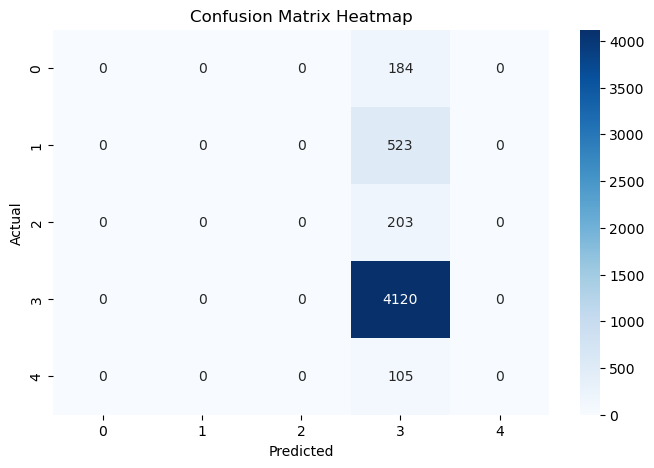

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1. Target column ke liye alag se encoder banayein
target_le = LabelEncoder()
data['Target'] = target_le.fit_transform(data['Target'].astype(str))

# 2. Ab 'Target' ke classes humein yahan se mil jayenge
class_names = target_le.classes_

# 3. Heatmap plot karein
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

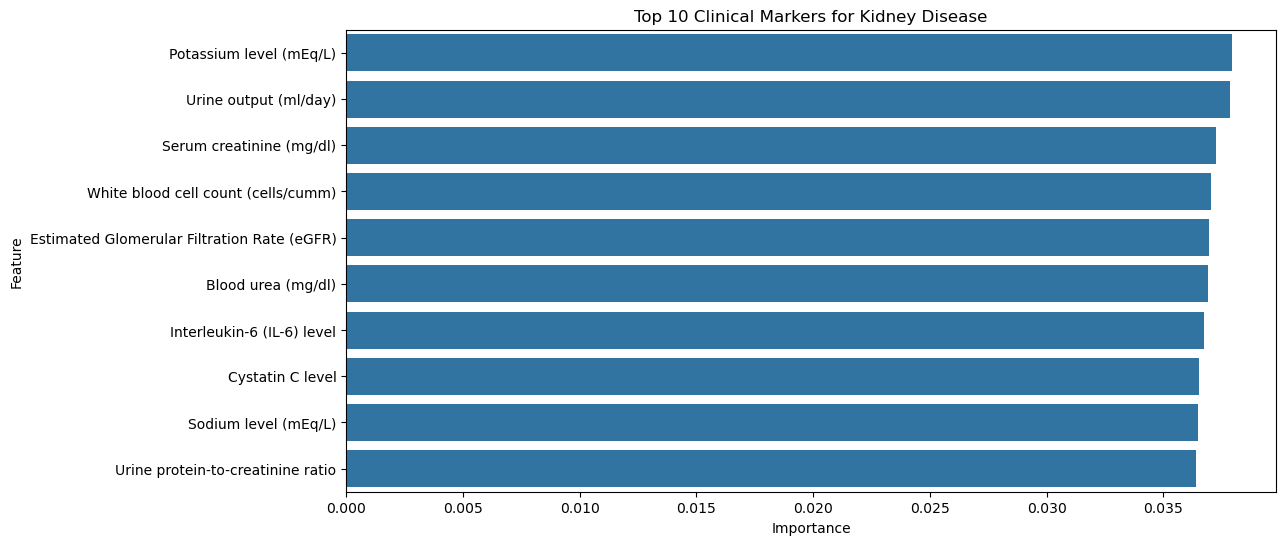

In [90]:
# Top 10 features nikalna
importances = classifier.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot karna
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Clinical Markers for Kidney Disease')
plt.show()

In [92]:
import pickle

# Model aur Encoders ko save karna
with open('kidney_model.pkl', 'wb') as f:
    pickle.dump({'model': classifier, 'encoders': encoders, 'scaler': sc}, f)

print("Model successfully saved as kidney_model.pkl!")

Model successfully saved as kidney_model.pkl!


In [94]:
from sklearn.model_selection import GridSearchCV

# Parameters ki list jo hum check karna chahte hain
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Grid Search setup
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Best settings milne ke baad
best_classifier = grid_search.best_params_
print(f"Best Parameters: {best_classifier}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
import pandas as pd
import numpy as np

# 1. Define the new patient's health markers
new_patient_data = {
    'Age of the patient': 54,
    'Blood pressure (mm/Hg)': 167,
    'Specific gravity of urine': 1.023,
    'Albumin in urine': 1,
    'Sugar in urine': 4,
    'Red blood cells in urine': 'normal',
    'Pus cells in urine': 'abnormal',
    'Pus cell clumps in urine': 'not present',
    'Bacteria in urine': 'not present',
    'Random blood glucose level (mg/dl)': 96,
    # ... (Include all other 42 columns here)
}

# 2. Convert to a DataFrame (the model expects a table, not a list)
new_df = pd.DataFrame([new_patient_data])

In [43]:
# Apply the encoders we saved during training
for col in categorical_cols:
    if col in new_df.columns:
        # Use the encoder's transform method
        new_df[col] = encoders[col].transform(new_df[col].astype(str))

# Fill any missing values using the imputer from earlier
new_df_imputed = imputer.transform(new_df)

NameError: name 'categorical_cols' is not defined

In [ ]:
# 1. Run the prediction
numeric_prediction = rf_model.predict(new_df_imputed)

# 2. Convert number back to text (e.g., 3 -> 'No_Disease')
final_diagnosis = encoders['Target'].inverse_transform(numeric_prediction)

print(f"🩺 Prediction for Patient: {final_diagnosis[0]}")

# 3. Check the "Confidence" (Probability)
probability = rf_model.predict_proba(new_df_imputed)
confidence = np.max(probability) * 100
print(f"📊 Confidence Score: {confidence:.2f}%")